In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Task 1: Data Preparation

The worksheet says to load the dataset using PIL, convert images to NumPy arrays, normalize them to 0–1, use the train folder for training and test folder for testing, resize to a consistent size such as 28×28, and convert labels to one-hot encoding for multi-class classification.

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.utils import to_categorical

# Dataset paths
train_dir = "/content/drive/MyDrive/Ai/DevanagariHandwrittenDigitDataset/DevanagariHandwrittenDigitDataset/Train"
test_dir = "/content/drive/MyDrive/Ai/DevanagariHandwrittenDigitDataset/DevanagariHandwrittenDigitDataset/Test"

# Image settings
img_height = 28
img_width = 28
num_classes = 10

def load_images_from_folder(folder):
    images = []
    labels = []

    class_names = sorted(os.listdir(folder))   # digit_0, digit_1, ..., digit_9
    class_map = {name: i for i, name in enumerate(class_names)}

    print("Class mapping:", class_map)

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)

        if not os.path.isdir(class_path):
            continue

        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)

            try:
                img = Image.open(img_path).convert("L")         # grayscale
                img = img.resize((img_width, img_height))      # resize to 28x28
                img = np.array(img, dtype=np.float32) / 255.0  # normalize

                images.append(img)
                labels.append(label)

            except Exception as e:
                print(f"Skipping {img_path}: {e}")

    return np.array(images, dtype=np.float32), np.array(labels, dtype=np.int32)

# Load dataset
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

# Reshape for keras
x_train = x_train.reshape(-1, img_height, img_width, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)

# One-hot encode labels
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape :", x_test.shape)
print("y_test shape :", y_test.shape)

Class mapping: {'digit_0': 0, 'digit_1': 1, 'digit_2': 2, 'digit_3': 3, 'digit_4': 4, 'digit_5': 5, 'digit_6': 6, 'digit_7': 7, 'digit_8': 8, 'digit_9': 9}
Class mapping: {'digit_0': 0, 'digit_1': 1, 'digit_2': 2, 'digit_3': 3, 'digit_4': 4, 'digit_5': 5, 'digit_6': 6, 'digit_7': 7, 'digit_8': 8, 'digit_9': 9}
x_train shape: (17014, 28, 28, 1)
y_train shape: (17014, 10)
x_test shape : (3000, 28, 28, 1)
y_test shape : (3000, 10)


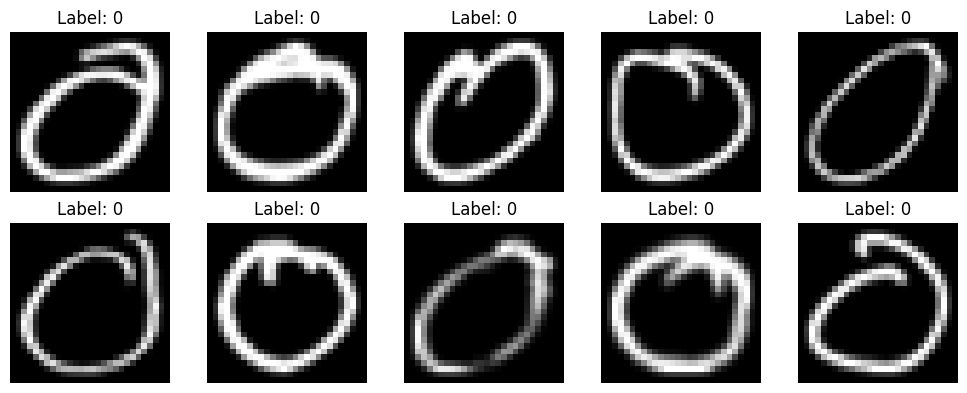

In [6]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap="gray")
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis("off")
plt.tight_layout()
plt.show()

Task 2: Build the FCN Model

The worksheet asks for a Sequential model with 3 hidden layers: 64, 128, and 256 neurons, all using sigmoid, followed by an output layer with 10 units and softmax.

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense

model = Sequential([
    Input(shape=(28, 28, 1)),
    Flatten(),
    Dense(64, activation="sigmoid"),
    Dense(128, activation="sigmoid"),
    Dense(256, activation="sigmoid"),
    Dense(10, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

Task 3: Compile the Model

The worksheet says to choose an appropriate optimizer such as Adam, a loss function such as sparse categorical crossentropy, and accuracy as a metric.

Because Task 1 also tells you to convert labels to one-hot encoded format, the correct loss for this code is categorical_crossentropy rather than sparse_categorical_crossentropy. Sparse categorical crossentropy is for integer labels, while categorical crossentropy is for one-hot encoded labels.

In [8]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

Task 4: Train the Model

The worksheet requires model.fit() with batch size 128, 20 epochs, and validation_split = 0.2. It also says callbacks like ModelCheckpoint and EarlyStopping can be used optionally.

In [9]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    "best_devnagari_fcn.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=128,
    callbacks=[checkpoint, early_stop],
    verbose=1
)

Epoch 1/20
103/107 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2628 - loss: 2.0238
Epoch 1: val_accuracy improved from None to 0.00088, saving model to best_devnagari_fcn.h5



Epoch 1: finished saving model to best_devnagari_fcn.h5
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.4585 - loss: 1.6585 - val_accuracy: 8.8158e-04 - val_loss: 7.3131
Epoch 2/20
106/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7952 - loss: 0.6889
Epoch 2: val_accuracy did not improve from 0.00088
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8189 - loss: 0.5601 - val_accuracy: 8.8158e-04 - val_loss: 8.4479
Epoch 3/20
101/107 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8994 - loss: 0.3392
Epoch 3: val_accuracy did not improve from 0.00088
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9101 - loss: 0.3082 - val_accuracy: 8.8158e-04 - val_loss: 8.9024
Epoch 4/20
106/107 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9419 - loss: 0.2149
Epoch 4: val_accuracy did not improve from 0.00088
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9462 - loss: 0.1972 - val_accuracy: 8.8158e-04 - val_loss: 9.3558
Epoch 5/20
102/107 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms

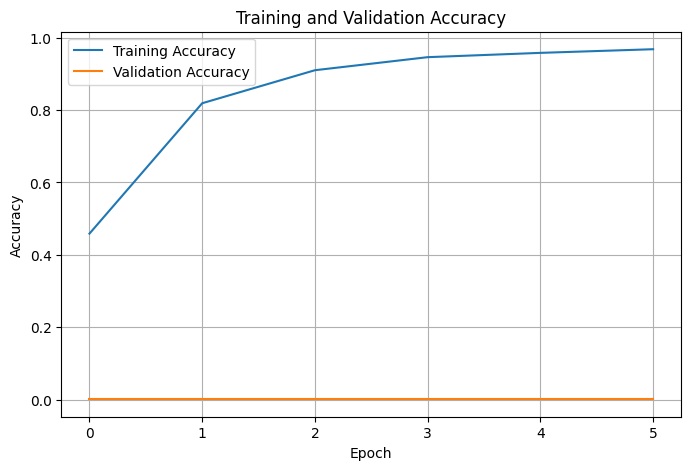

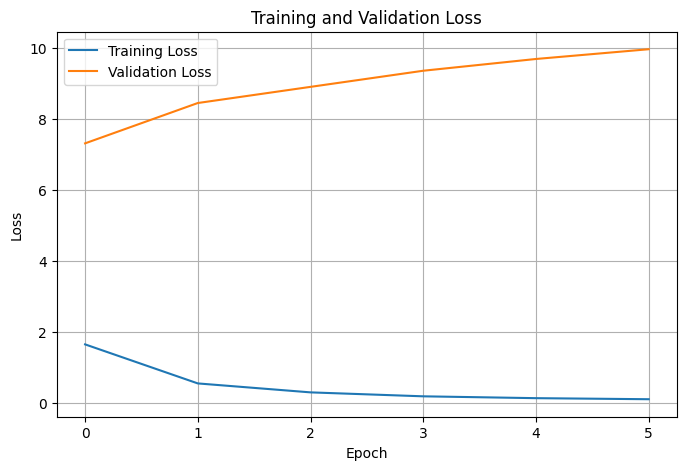

In [10]:
# Accuracy graph
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Loss graph
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [11]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=1)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6067 - loss: 2.1504
Test Loss: 2.150376081466675
Test Accuracy: 0.6066666841506958


In [12]:
from tensorflow.keras.models import load_model

# Save model
model.save("devnagari_fcn_model.h5")
print("Model saved successfully.")

# Load model
loaded_model = load_model("devnagari_fcn_model.h5")
print("Model loaded successfully.")

# Re-evaluate loaded model
loaded_loss, loaded_accuracy = loaded_model.evaluate(x_test, y_test, verbose=1)

print("Loaded Model Test Loss:", loaded_loss)
print("Loaded Model Test Accuracy:", loaded_accuracy)

Model saved successfully.
Model loaded successfully.
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6067 - loss: 2.1504
Loaded Model Test Loss: 2.150376081466675
Loaded Model Test Accuracy: 0.6066666841506958


In [13]:
# Predict probabilities
predictions = loaded_model.predict(x_test)

# Convert probabilities to class labels
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

print("First 10 predicted labels:", predicted_labels[:10])
print("First 10 true labels     :", true_labels[:10])

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
First 10 predicted labels: [0 0 0 0 0 0 0 0 0 0]
First 10 true labels     : [0 0 0 0 0 0 0 0 0 0]


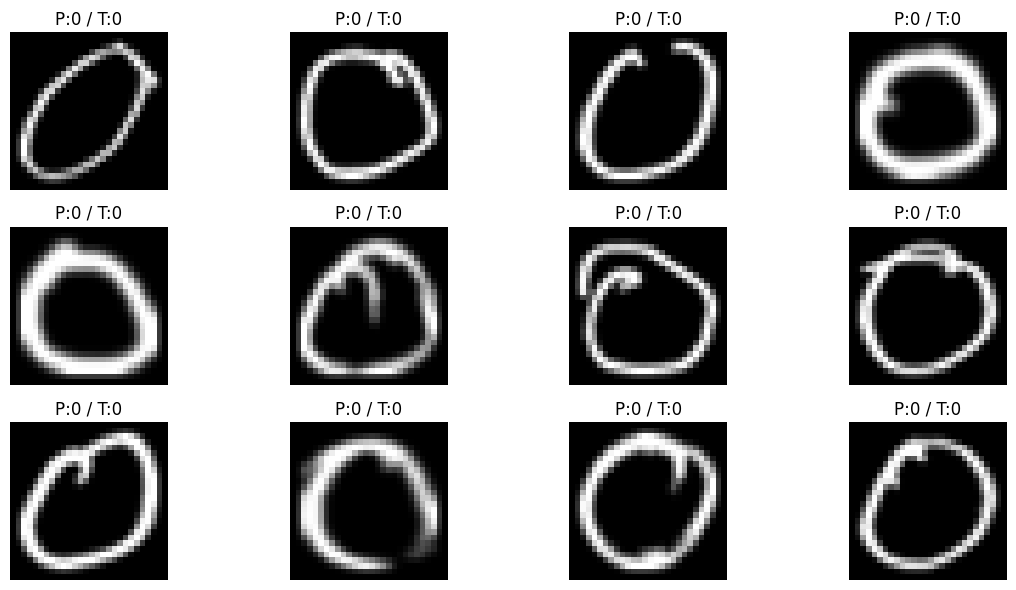

In [14]:
plt.figure(figsize=(12, 6))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.title(f"P:{predicted_labels[i]} / T:{true_labels[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()